# **Waste Classification Using CNN**

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image

In [16]:
import zipfile
import os

zip_path = "/Users/shwetatiwari/Downloads/archive (2).zip"
extract_path = "/Users/shwetatiwari/trashnet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [17]:
import os

print(os.listdir("/Users/shwetatiwari/trashnet"))

['dataset-resized']


## Dataset load

In [18]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/Users/shwetatiwari/trashnet/dataset-resized",
    image_size=(224, 224),
    batch_size=32
)

Found 2527 files belonging to 6 classes.


In [19]:
print(train_ds.class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# STEP 2 - ALL HYPERPARAMETERS IN ONE CONFIG BLOCK — CHANGE VALUES HERE ONLY

In [21]:
import os

# Dataset path
DATASET_DIR = "/Users/shwetatiwari/trashnet/dataset-resized"

# Image Settings
IMG_SIZE=(224,224)         # Resize all input images to 224x224 (MobileNetV2 default size)
IMG_SHAPE=(224,224,3)      # Shape of input tensor including 3 color channels (RGB)
BATCH_SIZE=32              # Number of images processed in one iteration during training

# Training Settings
EPOCHS_FROZEN=20          # Phase 1: Train only the custom classification head while keeping base model frozen
EPOCHS_FINE=25            # Phase 2: Fine-tune top layers of the base model along with the custom head
LEARNING_RATE=3e-4        # Learning rate for Phase 1 (faster learning for newly added head)
FINE_LR=2e-5              # Much slower learning rate for fine-tuning to avoid destroying pre-trained patterns
VAL_SPLIT=0.2            # 20% for testing, 80% for training

# Class names (IMPORTANT FIX)
CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
NUM_CLASS = len(CLASS_NAMES)

# Output path
MODEL_PATH = "waste_model.h5"

print(f"Classes found ({NUM_CLASS}): {CLASS_NAMES}")

Classes found (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [41]:
import json

# Save mapping
with open("class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)

print(" class_indices.json saved")

 class_indices.json saved


# STEP 3 - DATA LOADING & AUGMENTATION WITH ImageDataGenerator

**1. train_datagen** - To help the AI learn deep patterns and prevent it from "memorizing" the photos.

It uses Augmentation: It flips, rotates, and zooms images.

If the AI only sees a plastic bottle standing straight, it won't recognize it lying down. train_gen constantly "messes" with the photos so the AI is forced to learn what a bottle actually looks like, regardless of the angle.


**2. val_datagen** - To give a realistic score of how good your AI actually is.

No Augmentation: It does not rotate or flip the images. It only rescales them (0 to 1).

You want to test the AI on "clean," normal photos. If you also augmented the validation photos, your test results would be confusing—you wouldn't know if the AI is failing because the photo is "too messy" or because the AI is actually bad.

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training generator (with augmentation)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VAL_SPLIT
)

# Data Pipeline: Connecting Folders to the Model
train_gen=train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',    # Tells the AI there are multiple categories
    subset='training',           # Use the training portion only
    shuffle=True,                # Mix the photos so the AI doesn't memorize order
    seed=42                      # Keep the random mix the same every time we run it
)

val_gen=val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',         # Use the 20% we saved for testing
    shuffle=False,               # DO NOT mix; keep order to see which photos it gets wrong
    seed=42
)

print(f"\nTraining samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")
print(f"Class indices      : {train_gen.class_indices}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.

Training samples   : 2024
Validation samples : 503
Class indices      : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


# STEP 4- Visualize Sample Images of train_gen with Data Augmentation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4534617..0.8900969].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.97825].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.95866394..0.978117].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8776994].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.95680815..0.99872756].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98434323..0.8709965].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.636468..1.0].
Cli

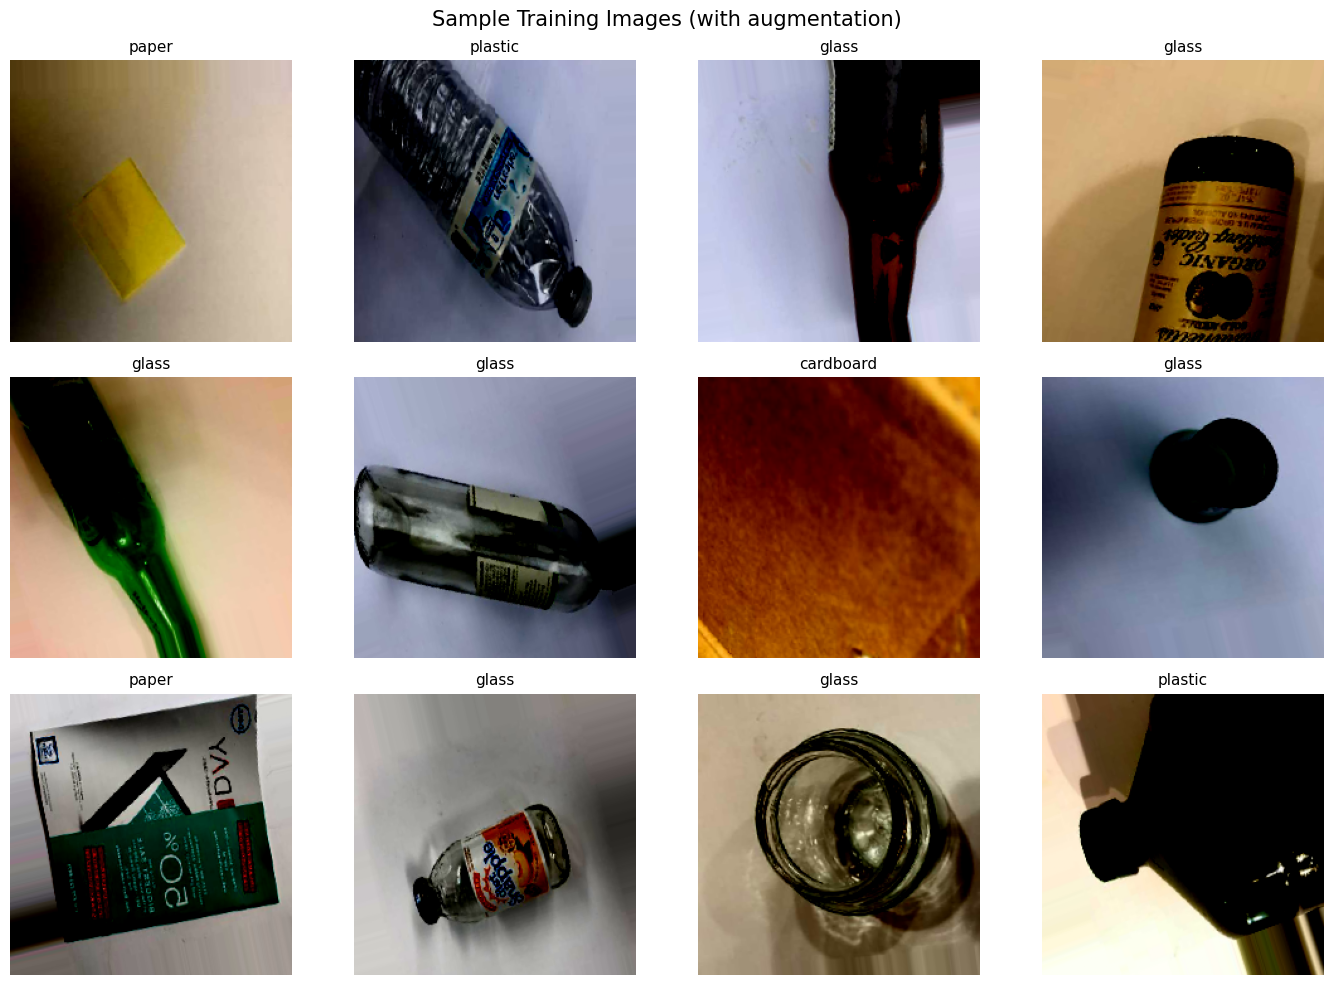

In [24]:
# Visualize a batch of sample images

def show_sample_images(generator,class_names,n=12):
  image,labels=next(generator)            # Grab one batch of data (32 images/labels) from the conveyor belt
  label_idx=np.argmax(labels,axis=1)            # Convert one-hot encoded labels [0,0,1] to class index (e.g., 2)

  fig,axes=plt.subplots(3,4,figsize=(14,10))                 # Create a grid of 3 rows and 4 columns for display
  fig.suptitle("Sample Training Images (with augmentation)", fontsize=15)        # Add a main title to the entire figure

  for i,ax in enumerate(axes.flat):
    if i<n:
      ax.imshow(image[i])                              # Display the i-th image from the batch
      ax.set_title(class_names[label_idx[i]],fontsize=11)      # Set the title of each image using the class name
      ax.axis('off')

  plt.tight_layout()
  plt.savefig("sample_images.png", dpi=120)            # Save the visual result as a high-quality PNG file
  plt.show()

show_sample_images(train_gen, CLASS_NAMES)

# STEP 5- COMPUTE CLASS WEIGHTS

**The Problem:** Majority Bias - If one category (e.g., Plastic) has 1000 images and another (e.g., Metal) has only 50, the AI will naturally learn to prefer the majority class to get a higher accuracy score, ignoring the rare ones.


**The Solution:** Weighted Learning

We calculate Class Weights to act as a "Fairness Meter." It tells the AI that mistakes on rare classes are more expensive than mistakes on common classes.

**Higher Weight:** Assigned to classes with fewer samples (e.g., Metal).

**Lower Weight:** Assigned to classes with many samples (e.g., Plastic).

In [25]:
all_labels=train_gen.classes     # ex: all_labels = [0, 0, 1, 2, 2, 2, 2, 2, 2, 2]

# Compute balanced class weights
class_weights_array=compute_class_weight(
    class_weight='balanced',        # 'balanced' mode automatically gives HIGHER weight to classes with FEWER images
    classes=np.unique(all_labels),  # [0,1,2,3,4,5] (Unique IDs)
    y=all_labels                    # The full list of labels used for counting frequency
)

# Convert to dict {class_index: weight} as Keras requires weights in a Dictionary format for model.fit()
class_weights_dict=dict(enumerate(class_weights_array))    # ex- {0: 1.66, 1: 3.33, 2: 0.47}

print("Class weights (higher = rarer class):")

# Loop through each class name to display its weight and total image count
for idx,name in enumerate(CLASS_NAMES):
  count=np.sum(all_labels==idx)          # Count how many times this specific index (idx) appears in all_labels
  print(f"{name:12s} -> weight {class_weights_dict[idx]:.3f} ({count} samples)")

Class weights (higher = rarer class):
cardboard    -> weight 1.044 (323 samples)
glass        -> weight 0.841 (401 samples)
metal        -> weight 1.028 (328 samples)
paper        -> weight 0.709 (476 samples)
plastic      -> weight 0.874 (386 samples)
trash        -> weight 3.067 (110 samples)


# STEP 6 - TRAIN THE MODEL

**Build MobileNetV2 + custom head**

1. We use MobileNetV2 as base model (pretrained on ImageNet)
2. Remove its top layer (include_top=False) → because original model is for 1000 classes
3. Freeze base model (trainable=False) → to retain learned features and avoid overfitting

**Custom Classification Head** - Add new layers on top for our task:

**GlobalAveragePooling → Dense → BatchNorm → Dropout → Softmax**




**Image**

 ↓

**MobileNetV2 (feature extraction)**

 ↓

**GlobalAveragePooling (convert to vector)**

 ↓

**Dense (learn task-specific features)**

 ↓

**BatchNormalization (stabilize training)**

 ↓

**Dropout (prevent overfitting)**

 ↓

**Softmax (final prediction)**


In [26]:
# Build MobileNetV2 + custom classification head

def build_model(IMG_SHAPE,NUM_CLASS):

# Load pre-trained base model (exclude top FC layers)
  base_model= MobileNetV2(
      input_shape=IMG_SHAPE,
      include_top=False,           # removes original classification layer (1000 classes)
      weights='imagenet',          # Uses ImageNet weights (already trained on large dataset)
      classifier_activation='softmax',
  )

# Freeze the base model (we train only our custom head first)
  base_model.trainable= False

 # Build the custom classification head

  inputs=tf.keras.Input(shape=IMG_SHAPE, name="input_image")
  x=base_model(inputs,training=False)        # Pass input through base model to extract features

  x=layers.GlobalAveragePooling2D()(x)       # Reduce spatial dims → vector, Convert feature maps (Hx W x C)

  x=layers.Dense(256,activation="relu")(x)   # Fully connected layer to learn task-specific patterns
  x=layers.BatchNormalization()(x)           # Normalize activations to stabilize and speed up training
  x=layers.Dropout(0.4)(x)                   # Randomly drop 40% neurons to prevent overfitting

  outputs = layers.Dense(NUM_CLASS, activation="softmax", name="predictions")(x) # NUM_CLASS neurons (one for each waste category),Softmax converts output into probabilities

  model = models.Model(inputs, outputs, name="WasteClassifier_MobileNetV2")     # Combine input and output to create final model
  return model, base_model

model, base_model = build_model(IMG_SHAPE, NUM_CLASS)

# Compile Phase 1: Train only the custom head (base model frozen)
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # Optimizer to update weights (Adam=fast & stable learning)
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)


model.summary()

9406464/9406464 [==============================] - 5s 1us/step


Model: "WasteClassifier_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                       

# STEP 7 - CALLBACK

Callbacks are automatic tools that monitor training and take actions like stopping early, saving the best model, or adjusting learning rate.

In [27]:
# Stops training if validation loss doesn't improve for 5 epochs and restores the best model weights.
early_stop=callbacks.EarlyStopping(
    monitor='val_loss',       # Track validation loss to check improvement
    patience=8,               # Wait 8 epochs before stopping if no improvement
    restore_best_weights=True,   # Load best model weights after stopping
    verbose=1                    # Print messages when stopping occurs
)

# Save the best model weights during training
checkpoint=callbacks.ModelCheckpoint(
    filepath=MODEL_PATH,          # Path to save the model file
    monitor='val_accuracy',       # Track validation accuracy to decide best model
    save_best_only=True,          # Save only when performance improves
    save_weights_only=False,      # Save full model (architecture + weights)
    verbose=1
)

# Reduces learning rate when validation loss stops improving
lr_scheduler=callbacks.ReduceLROnPlateau(
    monitor='val_loss',         # Track validation loss
    factor=0.5,                 # Reduce learning rate by half
    patience=7,
    min_lr=1e-7,                # Minimum learning rate limit
    verbose=1
)

# This list will be passed to model.fit() so all callbacks run during training
all_callbacks=[early_stop,checkpoint,lr_scheduler]
print("Callbacks ready: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau")

Callbacks ready: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# STEP 8 - PHASE-1 TRAINING (FROZEN BASE)

Train the model (Phase 1) using training data while keeping base model frozen, evaluate on validation data each epoch, apply callbacks for optimization, and track performance (accuracy & loss) across epochs.

In [31]:
history_phase1 = model.fit(
    train_gen,
    epochs           = EPOCHS_FROZEN,
    validation_data  = val_gen,
    class_weight     = class_weights_dict,
    callbacks        = all_callbacks,
    verbose          = 1
)

print(f"\nPhase 1 complete.")
print(f"Best val_accuracy : {max(history_phase1.history['val_accuracy']):.4f}")

Epoch 1/20
64/64 [==============================] - ETA: 0s - loss: 0.2227 - accuracy: 0.9130
Epoch 1: val_accuracy did not improve from 0.82903
64/64 [==============================] - 18s 284ms/step - loss: 0.2227 - accuracy: 0.9130 - val_loss: 0.5575 - val_accuracy: 0.8151 - lr: 1.0000e-05
Epoch 2/20
64/64 [==============================] - ETA: 0s - loss: 0.1932 - accuracy: 0.9239
Epoch 2: val_accuracy did not improve from 0.82903
64/64 [==============================] - 18s 287ms/step - loss: 0.1932 - accuracy: 0.9239 - val_loss: 0.5528 - val_accuracy: 0.8211 - lr: 1.0000e-05
Epoch 3/20
64/64 [==============================] - ETA: 0s - loss: 0.1938 - accuracy: 0.9254
Epoch 3: val_accuracy did not improve from 0.82903
64/64 [==============================] - 19s 299ms/step - loss: 0.1938 - accuracy: 0.9254 - val_loss: 0.5804 - val_accuracy: 0.8151 - lr: 1.0000e-05
Epoch 4/20
64/64 [==============================] - ETA: 0s - loss: 0.1977 - accuracy: 0.9229
Epoch 4: val_accuracy di

# STEP 9 - PHASE 2 FINE-TUNING

In this phase, the top layers of the pretrained MobileNetV2 model are unfrozen to allow further learning.
Only the last few layers are trained while keeping earlier layers frozen to preserve general features.

The model is recompiled with a lower learning rate to ensure slow and safe updates without damaging pretrained weights.

Then, the model is trained again using training and validation data, along with callbacks for better control.

This step helps the model adapt more precisely to the waste classification task and improves overall performance.

In [32]:
# Unfreeze the top 30 layers of the base model
base_model.trainable=True
UNFREEZE_FROM=len(base_model.layers)-30

for i, layer in enumerate(base_model.layers):
    # Freeze the BatchNorm layers
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = (i >= UNFREEZE_FROM)

# Recompile with a much lower learning rate (to avoid destroying pretrained weights)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_LR),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)
trainable_count=0
for l in base_model.layers:
  if l.trainable:
    trainable_count+=1

print(f"Unfrozen base layers : {trainable_count} / {len(base_model.layers)}")
print(f"Fine-tune LR         : {FINE_LR}")

history_phase2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINE,
    validation_data=val_gen,
    class_weight=class_weights_dict,
    callbacks=all_callbacks,
    verbose= 1
)

print(f"\nPhase 2 complete.")
print(f"Best val_accuracy : {max(history_phase2.history['val_accuracy']):.4f}")

Unfrozen base layers : 19 / 154
Fine-tune LR         : 2e-05
Epoch 1/25
64/64 [==============================] - ETA: 0s - loss: 0.1550 - accuracy: 0.9422
Epoch 1: val_accuracy did not improve from 0.84692
64/64 [==============================] - 19s 288ms/step - loss: 0.1550 - accuracy: 0.9422 - val_loss: 0.6513 - val_accuracy: 0.8072 - lr: 2.0000e-05
Epoch 2/25
64/64 [==============================] - ETA: 0s - loss: 0.1322 - accuracy: 0.9575
Epoch 2: val_accuracy did not improve from 0.84692
64/64 [==============================] - 20s 318ms/step - loss: 0.1322 - accuracy: 0.9575 - val_loss: 0.5606 - val_accuracy: 0.8171 - lr: 2.0000e-05
Epoch 3/25
64/64 [==============================] - ETA: 0s - loss: 0.1462 - accuracy: 0.9476
Epoch 3: val_accuracy did not improve from 0.84692
64/64 [==============================] - 21s 324ms/step - loss: 0.1462 - accuracy: 0.9476 - val_loss: 0.5595 - val_accuracy: 0.8052 - lr: 2.0000e-05
Epoch 4/25
64/64 [==============================] - ETA: 

# LOAD FOR TESTING

In [33]:
# Load model
model = tf.keras.models.load_model("waste_model.h5")

print("Model loaded successfully")
print("Classes:", CLASS_NAMES)

Model loaded successfully
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# VALIDATION GENERATOR

In [34]:
IMG_SHAPE=(224,224)
BATCH_SIZE=32

val_datagen=ImageDataGenerator(rescale=1.0/255)
val_gen=val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
print('Validation data ready')

Found 2527 images belonging to 6 classes.
Validation data ready


# MODEL EVALUATION

In [36]:
# Evaluate Model
loss,accuracy=model.evaluate(val_gen,verbose=1)

print("\n Loss:", round(loss, 4))
print("Accuracy:", round(accuracy * 100, 2), "%")

# Predictions
val_gen.reset()
y_pred_probs=model.predict(val_gen, verbose=1)
y_pred=np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_gen.classes

79/79 [==============================] - 11s 132ms/step - loss: 0.4122 - accuracy: 0.8556

 Loss: 0.4122
Accuracy: 85.56 %
79/79 [==============================] - 11s 143ms/step


# CLASSIFICATION REPORT

In [37]:
print("\n Classification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))


 Classification Report:

              precision    recall  f1-score   support

   cardboard       0.99      0.85      0.92       403
       glass       0.91      0.82      0.86       501
       metal       0.98      0.68      0.80       410
       paper       0.89      0.95      0.92       594
     plastic       0.67      0.97      0.79       482
       trash       0.91      0.72      0.80       137

    accuracy                           0.86      2527
   macro avg       0.89      0.83      0.85      2527
weighted avg       0.88      0.86      0.86      2527



# CONFUSION MATRIX

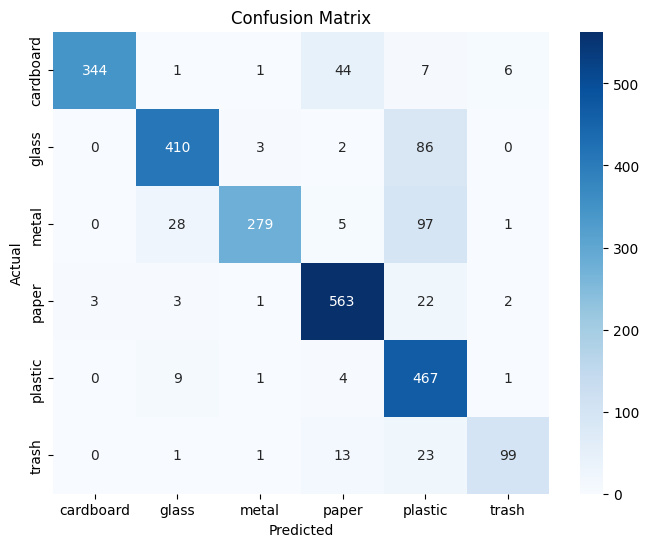

<Figure size 640x480 with 0 Axes>

In [38]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.savefig("confusion_matrix.png")

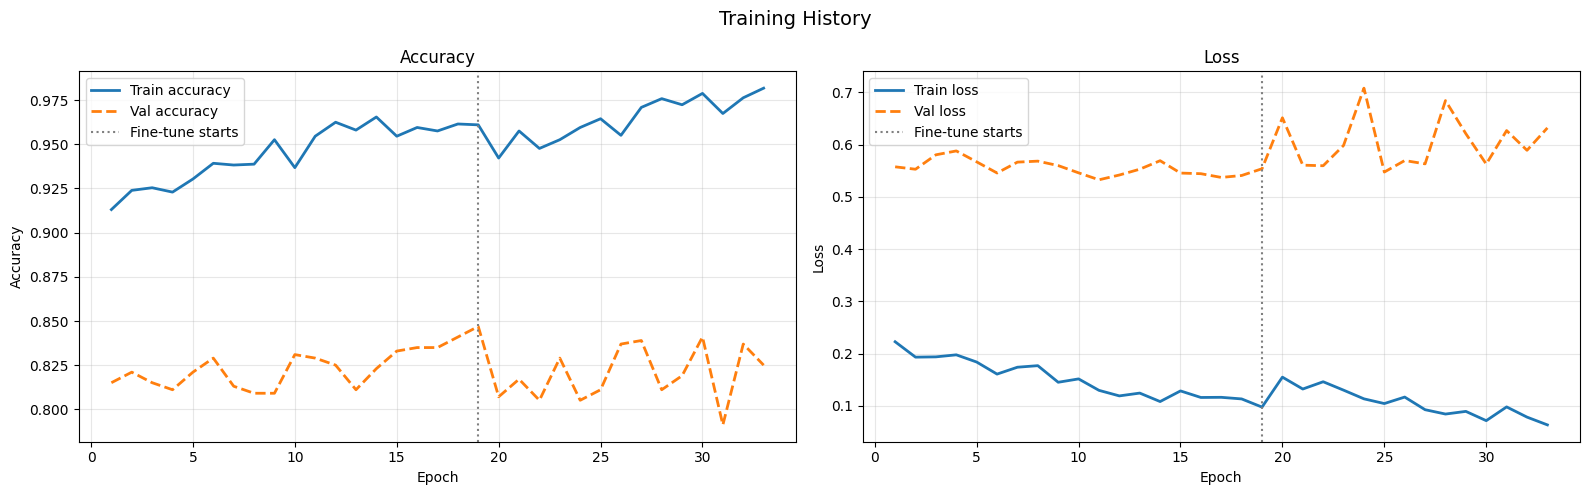

Saved: training_curves.png

Final train accuracy : 0.9817
Final val accuracy   : 0.8250
Generalisation gap   : 0.1567
Model appears well-generalised.


In [39]:
# Merge histories & plot accuracy / loss curves

def merge_histories(h1, h2):
    """Concatenate two Keras History objects into one dict."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_histories(history_phase1, history_phase2)

def plot_training_curves(history):
    """Plot accuracy and loss for train vs validation."""
    epochs = range(1, len(history["accuracy"]) + 1)
    phase1_end = len(history_phase1.history["accuracy"])  # Mark phase boundary

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Training History", fontsize=14)

    # --- Accuracy ---
    ax1.plot(epochs, history["accuracy"],     label="Train accuracy", linewidth=2)
    ax1.plot(epochs, history["val_accuracy"], label="Val accuracy",   linewidth=2, linestyle="--")
    ax1.axvline(x=phase1_end, color="gray", linestyle=":", label="Fine-tune starts")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Loss ---
    ax2.plot(epochs, history["loss"],     label="Train loss", linewidth=2)
    ax2.plot(epochs, history["val_loss"], label="Val loss",   linewidth=2, linestyle="--")
    ax2.axvline(x=phase1_end, color="gray", linestyle=":", label="Fine-tune starts")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120)
    plt.show()
    print("Saved: training_curves.png")

plot_training_curves(history)

# --- Overfitting / Underfitting Diagnosis ---
final_train_acc = history["accuracy"][-1]
final_val_acc   = history["val_accuracy"][-1]
gap             = final_train_acc - final_val_acc

print(f"\nFinal train accuracy : {final_train_acc:.4f}")
print(f"Final val accuracy   : {final_val_acc:.4f}")
print(f"Generalisation gap   : {gap:.4f}")

if gap >= 0.16:
    print("⚠ High gap → possible OVERFITTING. Try more dropout or less fine-tuning.")
elif final_val_acc < 0.70:
    print("⚠ Low val accuracy → possible UNDERFITTING. Try more epochs or unfreeze more layers.")
else:
    print("Model appears well-generalised.")

# PRE-CLASS ACCURACY

In [40]:
print("\n Per-Class Accuracy:\n")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for i, cls in enumerate(CLASS_NAMES):
    acc_cls = cm_norm[i, i] * 100
    status = "✅" if acc_cls >= 75 else "⚠️"
    print(f"{status} {cls:12s} : {acc_cls:.2f}%")


 Per-Class Accuracy:

✅ cardboard    : 85.36%
✅ glass        : 81.84%
⚠️ metal        : 68.05%
✅ paper        : 94.78%
✅ plastic      : 96.89%
⚠️ trash        : 72.26%


In [48]:
import json
import os
import shutil

# CLASS INDEX SAVE

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

with open("class_indices.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved: class_indices.json")

# CONFIRM MODEL FILE EXISTS

MODEL_PATH = "waste_model.h5"

if os.path.exists(MODEL_PATH):
    print(f"Saved: {MODEL_PATH}")
else:
    print("⚠ Model file not found! Check ModelCheckpoint step.")

# CHECK OTHER OUTPUT FILES

files_to_check = [
    "training_curves.png",
    "confusion_matrix.png"
]

for file in files_to_check:
    if os.path.exists(file):
        print(f"Saved: {file}")
    else:
        print(f"⚠ Missing: {file}")

# DISPLAY MAPPING

print("\nClass Index Mapping:")
print(json.dumps(idx_to_class, indent=2))

# COPY TO DOWNLOADS 

DOWNLOAD_DIR = "/Users/shwetatiwari/Downloads/"

if os.path.exists(DOWNLOAD_DIR):
    shutil.copy(MODEL_PATH, DOWNLOAD_DIR)
    shutil.copy("class_indices.json", DOWNLOAD_DIR)
    print("\nCopied model + json to Downloads folder")
else:
    print("\nDownloads folder not found")

Saved: class_indices.json
Saved: waste_model.h5
Saved: training_curves.png
Saved: confusion_matrix.png

Class Index Mapping:
{
  "0": "cardboard",
  "1": "glass",
  "2": "metal",
  "3": "paper",
  "4": "plastic",
  "5": "trash"
}

Copied model + json to Downloads folder


In [49]:
import json

# save class mapping v2
with open("class_indices_v2.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved class_indices_v2.json")

Saved class_indices_v2.json


In [50]:
model.save("waste_model_v2.h5")
print("Saved waste_model_v2.h5")

Saved waste_model_v2.h5


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [51]:
import tensorflow as tf

# Load karo
model = tf.keras.models.load_model("waste_model_v2.h5")

# Re-save karo SavedModel format mein
model.save("waste_model_fixed", save_format="tf")

print("✅ Done!")
print("waste_model_fixed folder ban gaya")

INFO:tensorflow:Assets written to: waste_model_fixed/assets


INFO:tensorflow:Assets written to: waste_model_fixed/assets


✅ Done!
waste_model_fixed folder ban gaya
